In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
print('loaded successfully')


loaded successfully


In [2]:
data=pd.read_csv('students-data.csv')
data

,Study Hours,Sleep Hours,Social Activity,Exam Score,Pass
0,5.8,5.5,High,75.8,Yes
1,4.8,5.8,Low,64.4,No
2,6.1,7.4,Medium,65.5,Yes
3,7.6,7.2,High,100.1,Yes
4,4.6,6.5,High,54.2,No
...,...,...,...,...,...
295,3.8,5.9,High,59.9,Yes
296,6.5,6.2,High,84.2,Yes
297,5.5,5.3,Medium,69.1,Yes
298,6.4,6.0,Medium,66.9,Yes


In [3]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Study Hours      300 non-null    float64
 1   Sleep Hours      300 non-null    float64
 2   Social Activity  300 non-null    object 
 3   Exam Score       300 non-null    float64
 4   Pass             300 non-null    object 
dtypes: float64(3), object(2)
memory usage: 11.8+ KB


In [4]:
data.describe().T

,count,mean,std,min,25%,50%,75%,max
Study Hours,300.0,4.992333,1.671493,-0.5,3.800,5.1,6.10,11.5
Sleep Hours,300.0,6.472667,1.154366,3.5,5.675,6.5,7.20,10.2
Exam Score,300.0,68.274333,20.015809,6.8,55.525,67.2,79.65,135.8


In [5]:
data.shape

(300, 5)

In [6]:
data.isnull().sum()

Study Hours        0
Sleep Hours        0
Social Activity    0
Exam Score         0
Pass               0
dtype: int64

visualization

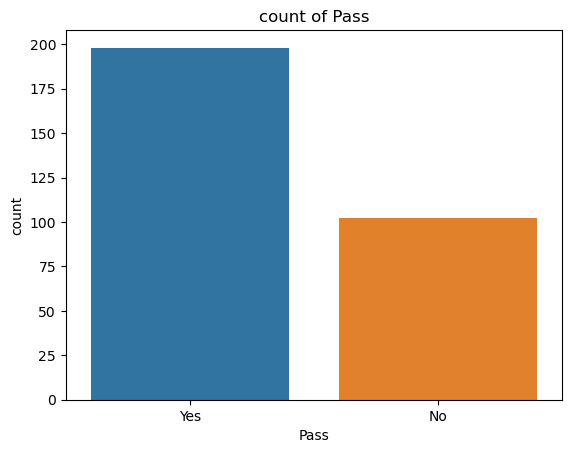

In [7]:
sns.countplot(x='Pass', data=data)
plt.title('count of Pass')
plt.show()

Relationship between the columns

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


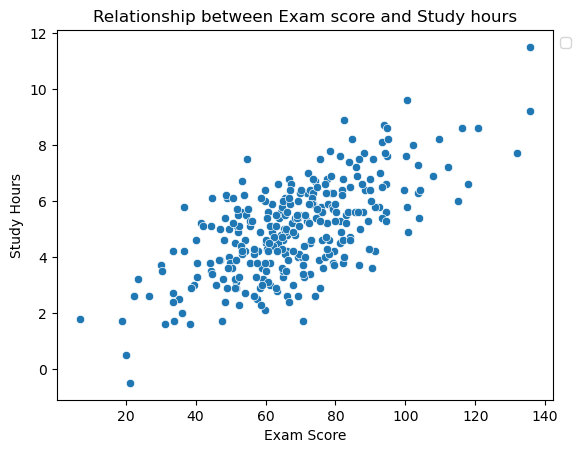

In [8]:
sns.scatterplot(x='Exam Score', y='Study Hours', data=data, )
plt.xlabel('Exam Score')
plt.ylabel('Study Hours')
plt.title('Relationship between Exam score and Study hours')
plt.legend(bbox_to_anchor=(1,1), loc=2)
plt.show()

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


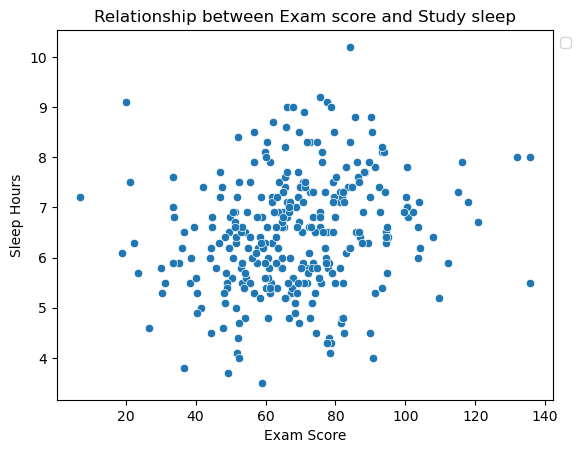

In [9]:
sns.scatterplot(x='Exam Score', y='Sleep Hours', data=data, )
plt.xlabel('Exam Score')
plt.ylabel('Sleep Hours')
plt.title('Relationship between Exam score and Study sleep')
plt.legend(bbox_to_anchor=(1,1), loc=2)
plt.show()

C:\Users\PC\.idlerc\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\PC\.idlerc\Lib\site-packages\seaborn\_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
C:\Users\PC\.idlerc\Lib\site-packages\seaborn\_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
C:\Users\PC\.idlerc\Lib\site-packages\seaborn\_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you

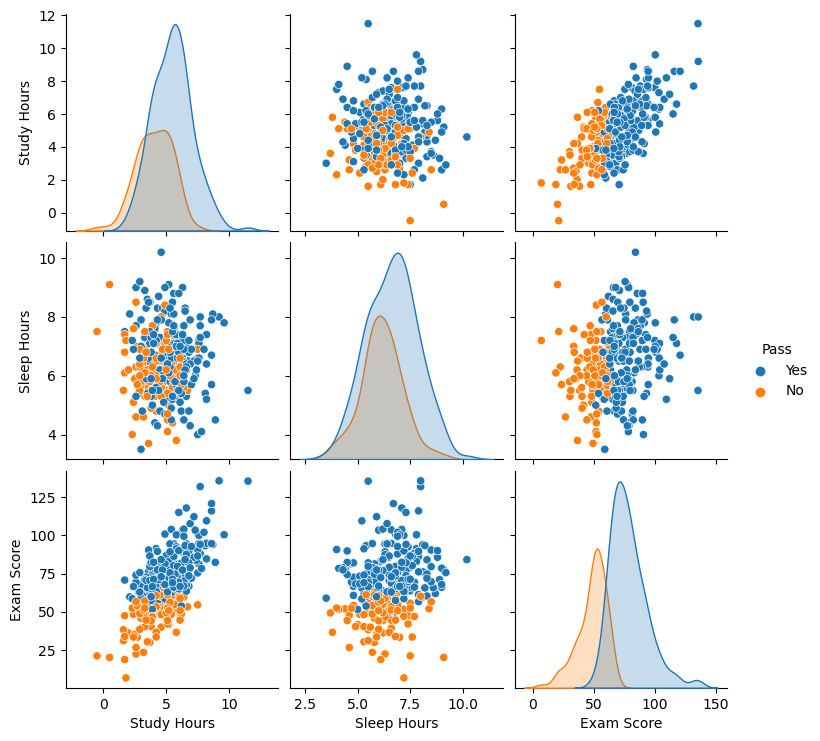

In [10]:
sns.pairplot(data, hue='Pass')
plt.show()

Feature Encoding and Selection

In [11]:
encoded_data=pd.get_dummies(data, columns=['Social Activity'], drop_first=True)
encoded_data.head()

,Study Hours,Sleep Hours,Exam Score,Pass,Social Activity_Low,Social Activity_Medium
0,5.8,5.5,75.8,Yes,False,False
1,4.8,5.8,64.4,No,True,False
2,6.1,7.4,65.5,Yes,False,True
3,7.6,7.2,100.1,Yes,False,False
4,4.6,6.5,54.2,No,False,False


Split the features and target

In [12]:
X=encoded_data.drop('Pass', axis=1,)
y=encoded_data['Pass'].map({'Yes':1, 'No':0})

In [13]:
from sklearn.model_selection import train_test_split

In [14]:
X_train, X_test, y_train, y_test=train_test_split(X, y, test_size=0.2, random_state=1)

Train the Model

In [15]:
from sklearn.tree import DecisionTreeClassifier

In [16]:
model=DecisionTreeClassifier(random_state=1, criterion='entropy', max_depth=3)

In [17]:
#fit the model
model.fit(X_train, y_train)

DecisionTreeClassifier(criterion='entropy', max_depth=3, random_state=1)

Visualize the Tree

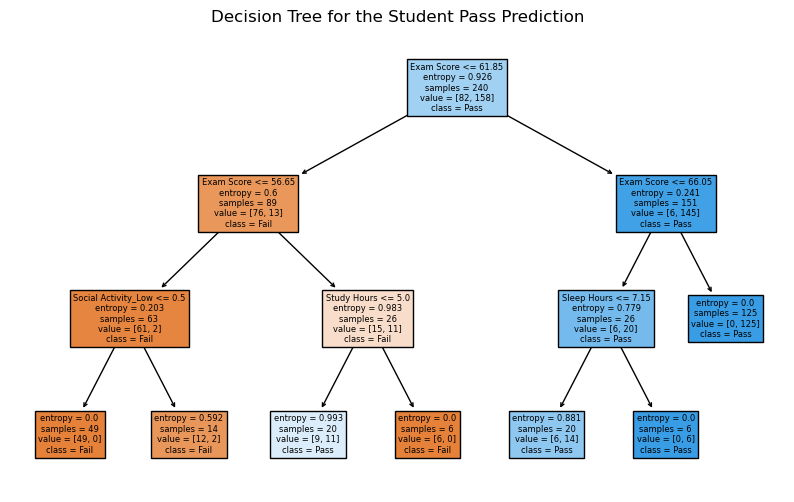

In [25]:
from sklearn.tree import plot_tree
plt.figure(figsize=(10,6))
plot_tree(model, feature_names=X.columns.tolist(), class_names=['Fail', 'Pass'], filled=True)
plt.title('Decision Tree for the Student Pass Prediction')
plt.show()
 

Model Evaluation and Accuracy Check

Accuracy 0.9333333333333333
Classification Report:
               precision    recall  f1-score   support

           0       0.94      0.85      0.89        20
           1       0.93      0.97      0.95        40

    accuracy                           0.93        60
   macro avg       0.94      0.91      0.92        60
weighted avg       0.93      0.93      0.93        60



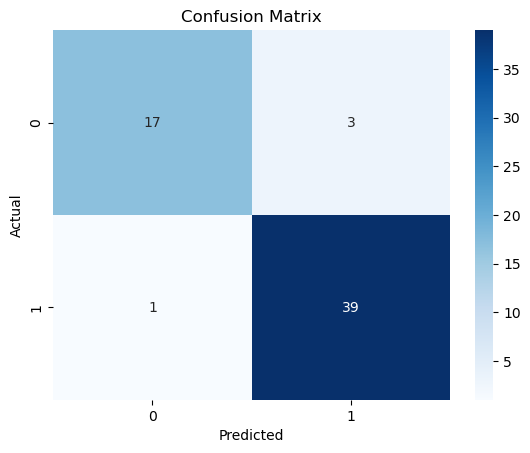

In [29]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
#prediction
y_pred=model.predict(X_test)

#Accuracy
print('Accuracy', accuracy_score(y_test, y_pred))
print('Classification Report:\n', classification_report(y_test, y_pred))

#Confusion Matrix
cm=confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d',cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

Save the Model

In [30]:
#save the model
import joblib

In [32]:
joblib.dump(model,'Student pass model prediction')

['Student pass model prediction']

In [37]:
#import model and make new prediction
loaded_model=joblib.load('student pass model prediction')

#make new prediction using a new data

sample_data=pd.DataFrame([[1, 6, 60, 0, 1]])
result=loaded_model.predict(sample_data)

print('Prediction:',['Fail' if r == 0 else 'Pass' for r in result])

Prediction: ['Pass']


C:\Users\PC\.idlerc\Lib\site-packages\sklearn\base.py:464: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
